In [1]:
# Find missing calibrations, and calibrations with large median error

import os
import pandas as pd

# Load the calibration_info.csv file
calibrations_info = pd.read_csv('calibration_info.csv')
calibrations_info.head()

,UniqueId,Name,Location,res_mean,res_median,res_std,res_max,res_min,gamma,kappa,...,lam,mup,sigp,rsmax,alpha,alpha1,alpha2,betam1,n,kappa_k
0,64,"Ono et al. 1989, CA025C",81828011-5b4b-4138-be69-3a1c47544fdf-007,0.056469,0.056308,0.000949,0.063178,0.054899,1.967600,1.072573,...,0.197418,6.702280,5.041588,0.991795,0.000617,0.364006,0.205205,0.020377,4.337753,0.249056
1,352,"Kunnath et al. 1997, A8",97dd05ce-a541-46a1-a5d2-5d5bf654cb6f-007,0.064116,0.064054,0.000396,0.066460,0.063446,0.349804,0.900517,...,0.840812,4.203175,5.221884,0.957630,0.004986,2.381744,0.327617,0.000686,2.661915,2.937689
2,379,"Sritharan et al. 1995, IC3",a815a3bf-1b81-4ae7-89dd-10555c1e48b0-007,0.086166,0.086095,0.001848,0.092875,0.080608,0.292919,1.001421,...,0.509318,2.958336,1.721987,0.994618,0.000254,6.175635,0.825094,0.000144,1.270288,4.382527
3,374,"Calderone et al. 2000, 328",f9585614-d99f-4ffe-8606-959791148bc5-007,0.069248,0.069533,0.002651,0.076363,0.061858,1.347681,1.065720,...,0.615313,1.344393,0.478505,0.658248,0.010387,3.755908,0.264980,0.005546,3.553621,0.336679
4,309,"NIST, Model N2",042badac-3f82-492d-9b57-ed6589371140-007,0.108375,0.108311,0.002932,0.118100,0.101374,1.432812,1.098083,...,0.242712,0.991950,0.496090,0.662467,0.000051,5.461077,1.802729,0.013241,1.412692,0.506857


In [2]:
# Load the calibrations_log.csv file inside quoFEM_TMCMC folder
calibrations_log = pd.read_csv(os.path.join('quoFEM_TMCMC', 'calibrations_log.csv'))
calibrations_log.head()

,calId,UniqueId,npts,folder
0,0,222,242,test_222
1,1,367,308,test_367
2,2,275,539,test_275
3,3,330,209,test_330
4,4,19,198,test_019


In [3]:
# Find missing UniqueIds in the calibrations_info file
missing_unique_ids = set(calibrations_log['UniqueId']) - set(calibrations_info['UniqueId'])
print(f"Missing UniqueIds: {missing_unique_ids}")

# Print how many missing UniqueIds there are
print(f"Number of missing UniqueIds: {len(missing_unique_ids)}")

Missing UniqueIds: {194, 325, 199, 9, 332, 77, 364, 143, 207, 49, 209, 241, 180, 336, 280}
Number of missing UniqueIds: 15


In [4]:
# Find UniqueIds with median error greater than 0.1 in the calibrations_info file
high_error_unique_ids = calibrations_info[calibrations_info['res_median'] > 0.1]['UniqueId']
print(f"UniqueIds with median error greater than 0.1: {high_error_unique_ids.tolist()}")

# Print how many UniqueIds have median error greater than 0.1
print(f"Number of UniqueIds with median error greater than 0.1: {len(high_error_unique_ids)}")

UniqueIds with median error greater than 0.1: [309, 196, 217, 15, 216, 302, 381, 195, 204, 205, 366, 98, 99, 345, 47, 28, 380, 340, 206, 193, 147, 117, 245, 189]
Number of UniqueIds with median error greater than 0.1: 24


In [5]:
# Add sets of missing UniqueIds and high error UniqueIds
combined_unique_ids = missing_unique_ids.union(set(high_error_unique_ids))
print(f"Combined UniqueIds (missing or high error): {combined_unique_ids}")

# Print how many UniqueIds are in the combined set
print(f"Number of UniqueIds in combined set: {len(combined_unique_ids)}")

Combined UniqueIds (missing or high error): {9, 143, 15, 147, 280, 28, 302, 47, 49, 180, 309, 189, 193, 194, 195, 196, 325, 199, 332, 77, 204, 207, 336, 209, 205, 206, 340, 216, 345, 217, 98, 99, 364, 366, 241, 117, 245, 380, 381}
Number of UniqueIds in combined set: 39


In [6]:
# Find the UniqueIds in the combined set in the calibrations_log file and extract the correspoding calId for each one and put in a list
calibration_ids = [calibrations_log[calibrations_log['UniqueId'] == unique_id]['calId'].values[0] for unique_id in combined_unique_ids]
# print(f"Calibration IDs for combined UniqueIds: {calibration_ids}")

# Print the combined set of UniqueIds as a list 10 at a time
for i in range(0, len(calibration_ids), 10):
    print(list(calibration_ids)[i:i+10])
    #print(list(combined_unique_ids)[i:i+10])


[103, 204, 19, 54, 25, 134, 155, 199, 123, 211]
[284, 10, 36, 126, 97, 216, 281, 112, 227, 287]
[96, 215, 101, 117, 128, 150, 127, 236, 234, 267]
[288, 223, 275, 73, 239, 86, 91, 168, 200]


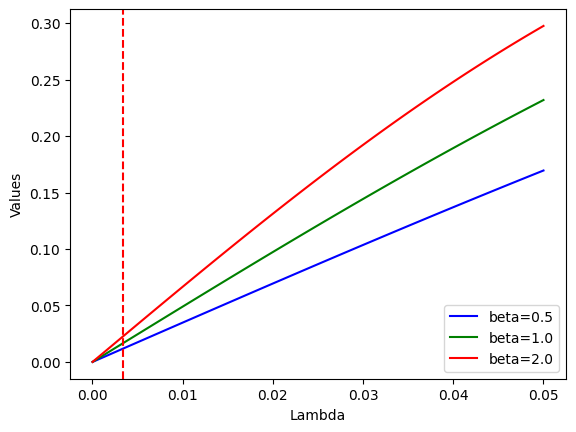

In [7]:



import numpy as np
import matplotlib.pyplot as plt
pi = np.pi

lam = np.linspace(0.00001, 0.05, 100)

betas = [0.5, 1.0, 2.0]
colors = ['b', 'g', 'r']
for beta, color in zip(betas, colors):
    lam_squared = lam**2
    C = np.sqrt((2*lam_squared*beta)**2 - 4*(4+lam_squared*beta*pi**4)*(lam_squared*beta**4 - 4*beta*pi**4/(beta*pi**4 + 4/lam_squared)))
    b = (2*lam_squared*beta + C)/(2*(4+lam_squared*beta*pi**4))
    a = 1 - b

    plt.plot(lam, b, label=f'beta={beta}', color=color)
    #plt.plot(lam, a, label=f'a (beta={beta})', linestyle='--', color=color)

plt.xlabel('Lambda')
plt.ylabel('Values')
plt.axvline(x=1/300, color='r', linestyle='--')
plt.legend()
plt.show()

